### Only using RESOLVE genes

In this notebook we see whether using only the targeted gene panel design by the Guilliams lab (used in the Molecular Cartography platform from Resolve Biosciences) would result in a cleaner UMAP.

In [1]:
import spatialdata as sd
import spatialdata_io
import spatialdata_plot
import sparrow as sp
from sparrow.io._visium_hd import visium_hd
import scanpy as sc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Import _rasterize_bins from ../scripts/utils
import sys
sys.path.append('../scripts')
from utils import _rasterize_bins

/home/chananchidas/miniconda3/envs/harpy2/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/chananchidas/miniconda3/envs/harpy2/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/home/chananchidas/miniconda3/envs/harpy2/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
2025-02-13 16:22:31,694 - sparrow.image.pixel_clustering._clustering - WARNING - 'flowsom' not installed, to use 'sp.im.flowsom', please install this library.
2

In [ ]:
sc.set_figure_params(facecolor="white", figsize=(8, 8))
sc.settings.n_jobs = 8
sc.settings.verbosity = 3
sc.settings.figdir = "./plots/"

In [3]:
sdata = sd.read_zarr('../data/Visium_HD_Liver/Visium_HD_Liver_zarr')

In [5]:
adata = sdata["square_008um"]

In [6]:
# Create a new table with the 100 genes from RESOLVE
resolve_adata = sc.read_h5ad("/home/chananchidas/Documents/resolve_test/adataNucA1-1.h5ad")

# Check how many genes of RESOLVE adata are in the Visium HD Liver adata
intersect_genes = list(set(adata.var_names) & set(resolve_adata.var_names))
print("There are " + str(len(intersect_genes)) + " genes in common between the two datasets.")

# Get the two genes not in the Visium HD Liver adata
print("Missing genes in Visium HD Liver adata:")
print(set(resolve_adata.var_names) - set(adata.var_names))

There are 95 genes in common between the two datasets.
Missing genes in Visium HD Liver adata:
{'Cx3cr1', 'Msln', 'Olfml3'}


In [7]:
# Subsetting the adata to only include the intersect genes
adata = adata[:, intersect_genes]
adata

View of AnnData object with n_obs × n_vars = 461427 × 95
    obs: 'cell_ID', 'in_tissue', 'array_row', 'array_col', 'fov_labels', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'clusters'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'clusters', 'clusters_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'spatialdata_attrs', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

## QC and preprocessing

In [8]:
adata.var["mt"] = adata.var_names.str.startswith("Mt-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], percent_top=[10], inplace=True)

/tmp/ipykernel_140662/12316007.py:1: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["mt"] = adata.var_names.str.startswith("Mt-")


In [9]:
adata.obs

,cell_ID,in_tissue,array_row,array_col,fov_labels,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,n_counts,clusters,pct_counts_in_top_10_genes
s_008um_00301_00321-1,252560,1,301,321,Visium_HD_Liver_square_008um_labels,5,1.791759,4.205408,1.649698,51.468988,60.282916,71.164309,100.000000,0.0,0.0,0.0,919.0,0,100.000000
s_008um_00602_00290-1,504767,1,602,290,Visium_HD_Liver_square_008um_labels,4,1.609438,4.013376,1.612110,45.280236,56.932153,71.681416,100.000000,0.0,0.0,0.0,678.0,4,100.000000
s_008um_00425_00829-1,356980,1,425,829,Visium_HD_Liver_square_008um_labels,2,1.098612,2.462290,1.241930,66.467066,81.437126,100.000000,100.000000,0.0,0.0,0.0,334.0,0,100.000000
s_008um_00526_00291-1,441080,1,526,291,Visium_HD_Liver_square_008um_labels,4,1.609438,3.601145,1.526305,43.035714,52.678571,62.678571,89.464286,0.0,0.0,0.0,1120.0,5,100.000000
s_008um_00128_00278-1,107543,1,128,278,Visium_HD_Liver_square_008um_labels,7,2.079442,6.690461,2.039981,46.240180,57.800224,69.584736,100.000000,0.0,0.0,0.0,891.0,5,99.999993
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
s_008um_00252_00421-1,211598,1,252,421,Visium_HD_Liver_square_008um_labels,12,2.564949,5.145732,1.815758,52.586697,59.323479,67.168846,79.562251,0.0,0.0,0.0,3518.0,0,91.946222
s_008um_00384_00793-1,322586,1,384,793,Visium_HD_Liver_square_008um_labels,1,0.693147,1.174823,0.776947,57.458564,71.270718,98.895028,100.000000,0.0,0.0,0.0,362.0,0,100.000000
s_008um_00565_00244-1,473715,1,565,244,Visium_HD_Liver_square_008um_labels,6,1.945910,5.766110,1.911926,50.540123,59.336420,69.444444,92.592593,0.0,0.0,0.0,1296.0,3,100.000008
s_008um_00353_00477-1,296292,1,353,477,Visium_HD_Liver_square_008um_labels,8,2.197225,6.026894,1.949745,44.768683,53.665480,63.843416,85.195730,0.0,0.0,0.0,1405.0,3,100.000000


In [10]:
# Remove the only 'cell' that encompasses the whole area?
sc.pp.filter_cells(adata, max_counts=3530000)

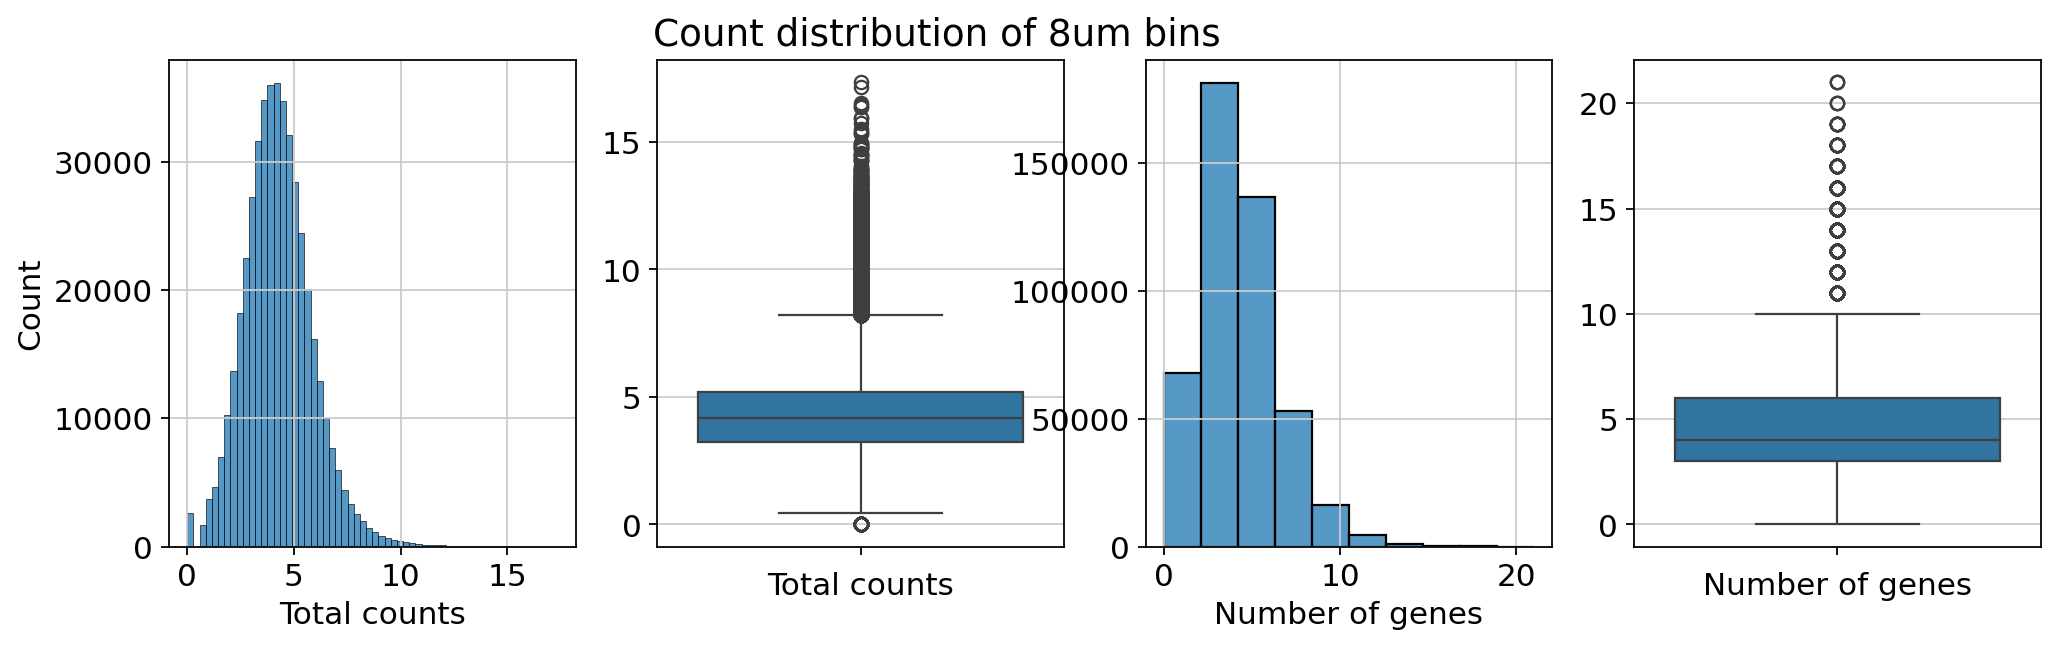

In [13]:
fig, axs = plt.subplots(1, 4, figsize=(15, 4))
sns.histplot(adata.obs["total_counts"], kde=False, bins=60, ax=axs[0])
sns.boxplot(adata.obs["total_counts"], ax=axs[1])

sns.histplot(adata.obs["n_genes_by_counts"], kde=False, bins=10, ax=axs[2])
sns.boxplot(adata.obs["n_genes_by_counts"], ax=axs[3])

# Set overall title
fig.suptitle("Count distribution of 8um bins")

# Set title and labels
axs[0].set_xlabel("Total counts")
axs[1].set_xlabel("Total counts")
axs[2].set_xlabel("Number of genes")
axs[3].set_xlabel("Number of genes")

# Turn off y-axis title
axs[1].set_ylabel("")
axs[2].set_ylabel("")
axs[3].set_ylabel("")

# Save plot
plt.savefig("plots/histogram_count_genes_8um_resolve.png", dpi=300)


In [14]:
adata.layers["counts"] = adata.X.copy()

In [15]:
sc.pp.normalize_total(adata, inplace=True)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, flavor="seurat")

normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


/home/chananchidas/scanpy/src/scanpy/preprocessing/_normalization.py:235: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))


## Manifold embedding and clustering based on transcriptional similarity

In [16]:
# Only ten highly variable genes were determined
adata.var['highly_variable'].sum()

10

In [ ]:
sc.pp.pca(adata, n_comps=10, use_highly_variable=False)
sc.pp.neighbors(adata, n_neighbors=15)
sc.tl.umap(adata)
sc.tl.leiden(
    adata, key_added="clusters", flavor="igraph", directed=False, n_iterations=2, resolution=0.8
)

We plot some covariates to check if there is any particular structure in the UMAP associated with total counts and detected genes.

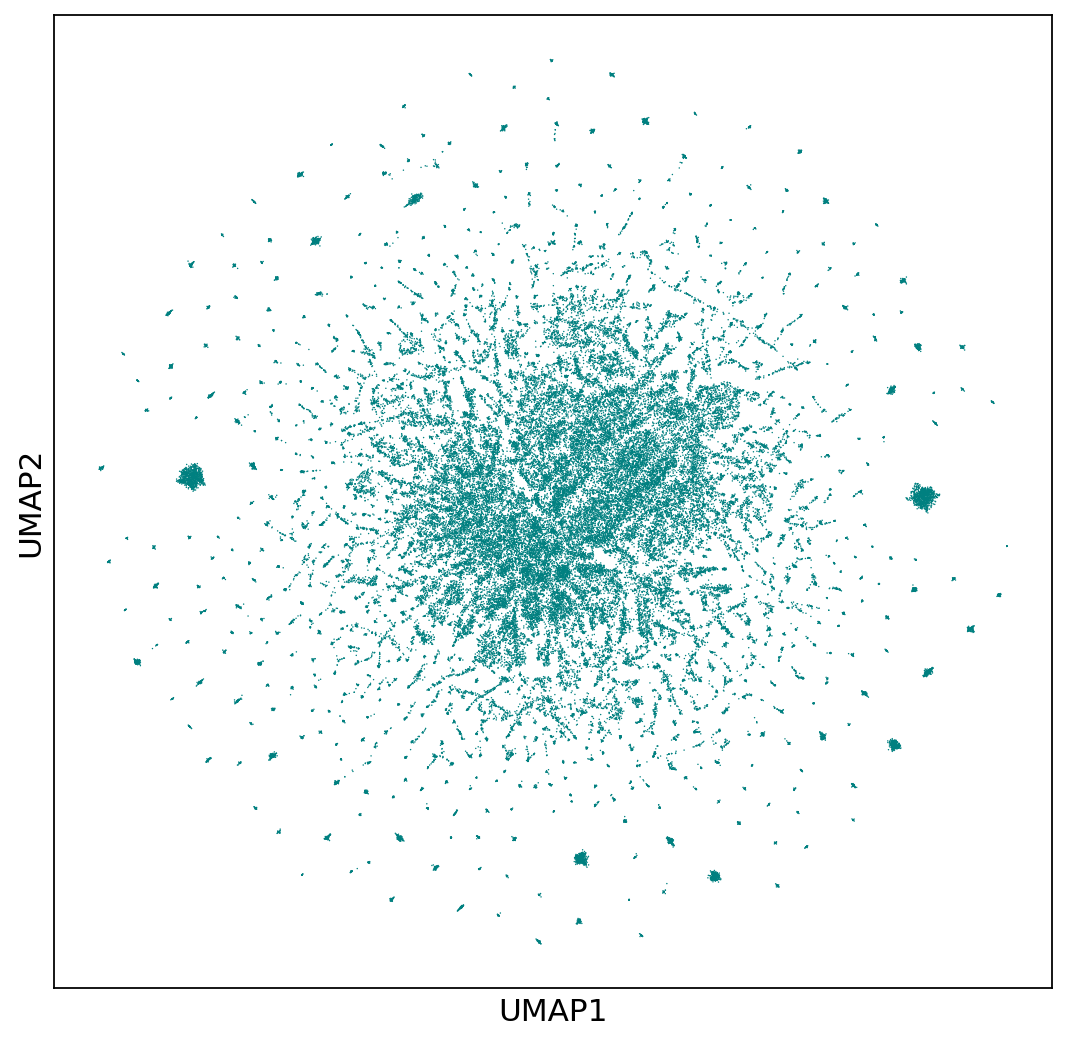

In [ ]:
sc.pl.umap(adata, na_color="teal")

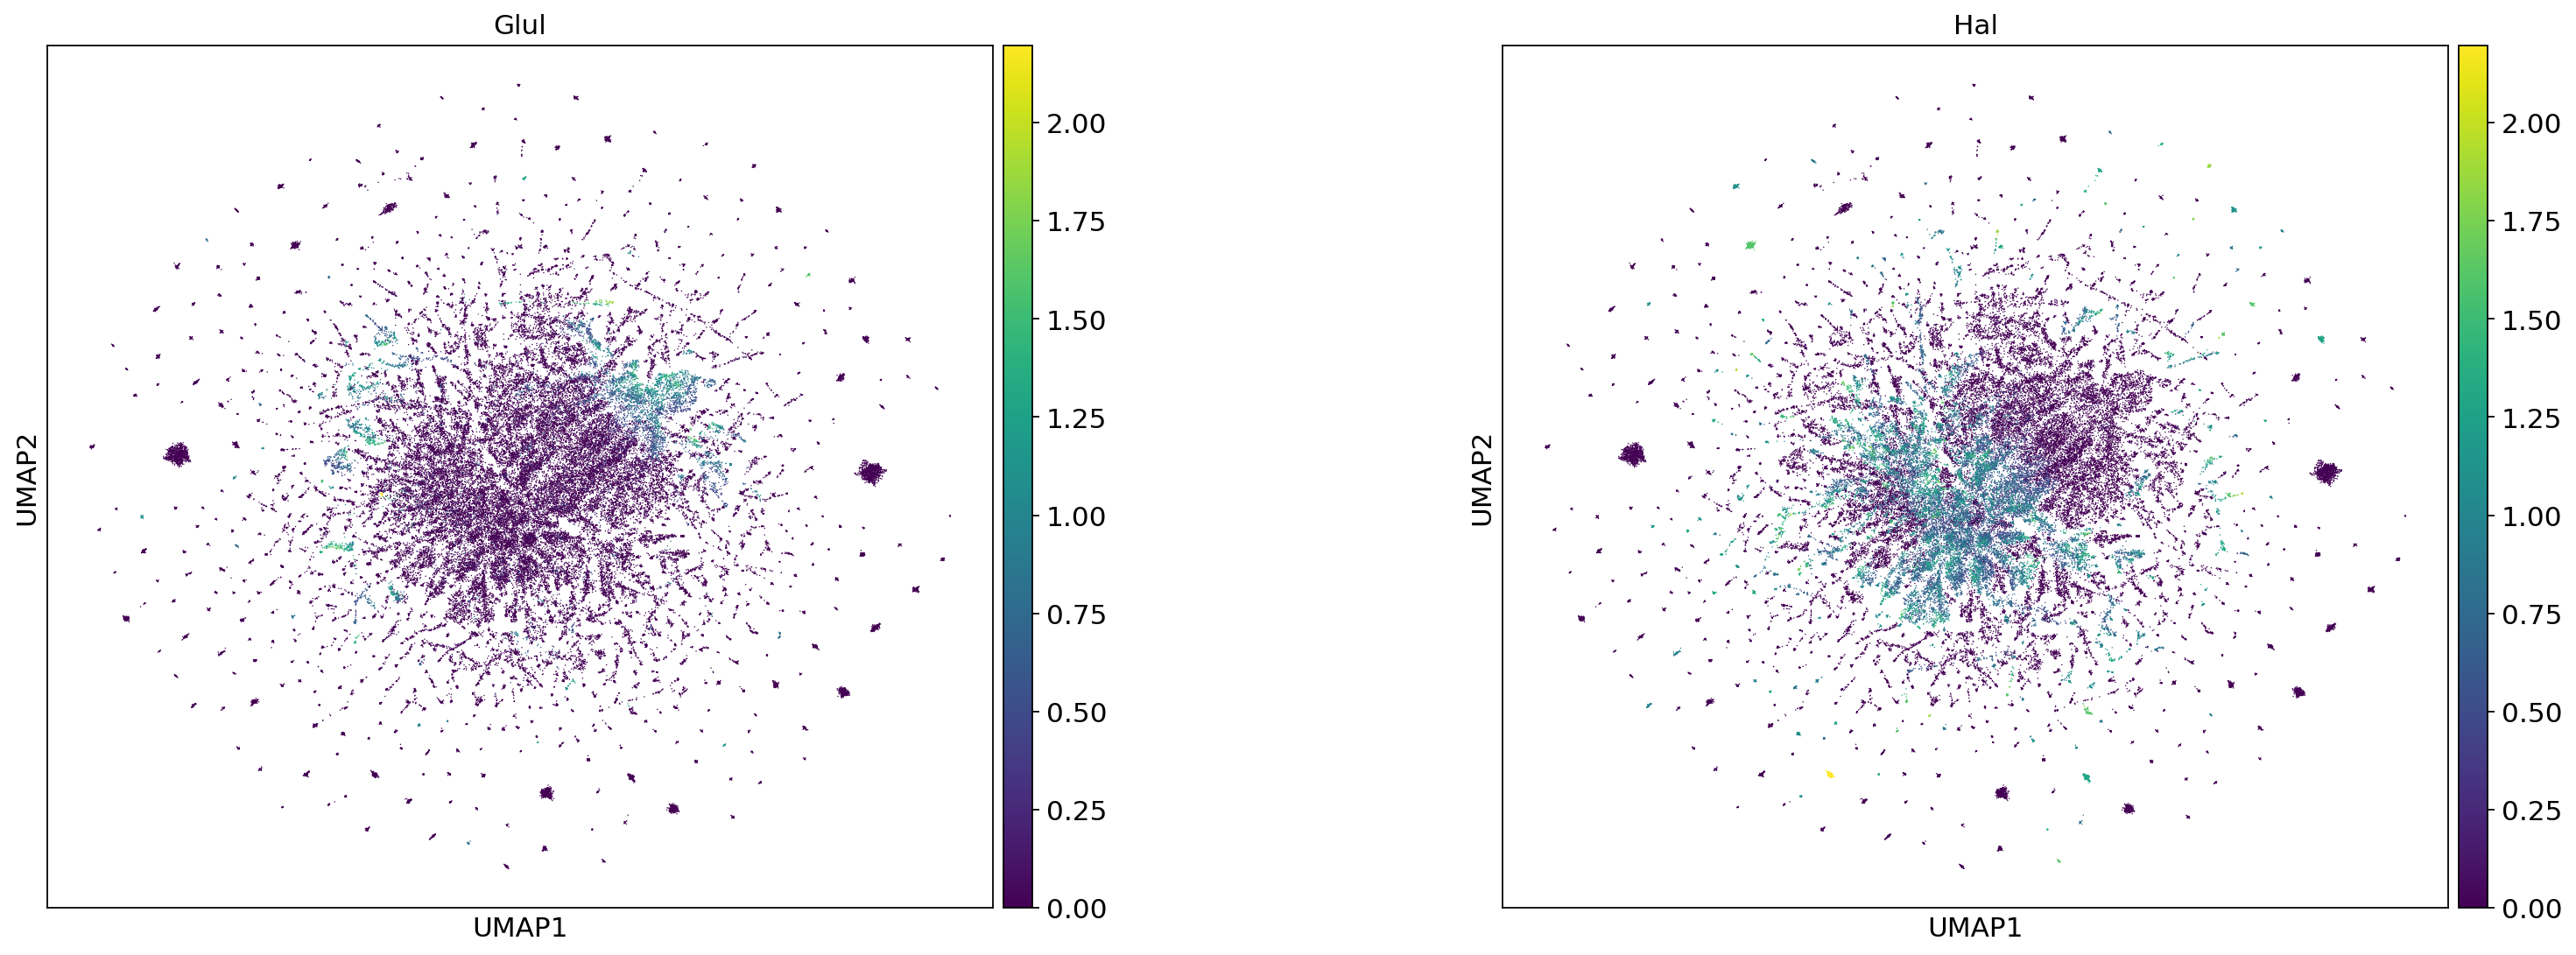

In [ ]:
# Plot some liver zonation markers
zonation_markers = ['Glul', 'Hal']
sc.pl.umap(adata, color=zonation_markers, wspace=0.4)       

In [ ]:
sdata['table_008um_resolve_pp'] = adata
sdata.write_element('table_008um_resolve_pp')